In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import dataframe_image as dfi
import folium
from folium.plugins import HeatMap

In [2]:
parent_dir = os.path.dirname(os.getcwd())
silver_data_path = parent_dir + '/data/2_silver/bus_gps_data.parquet'
gold_data_path = parent_dir + '/data/3_gold/dm_gold_data.parquet'
image_dir = parent_dir + '/images/'

# EDA for silver layer

In [22]:

# Thiết lập style cho biểu đồ nhìn hiện đại và chuyên nghiệp
sns.set_theme(style="whitegrid", context="talk")

df_eda = pd.read_parquet(silver_data_path, engine='pyarrow')

dfi.export(df_eda.describe(include='all'), image_dir + 'eda_silver.png', table_conversion='matplotlib')
df_eda = df_eda[((df_eda['door_up'] == True) | (df_eda['door_down'] == True))].copy()
df_eda = df_eda[(df_eda['station_distance'] < 100)]
p95_distance = df_eda['station_distance'].quantile(0.95)

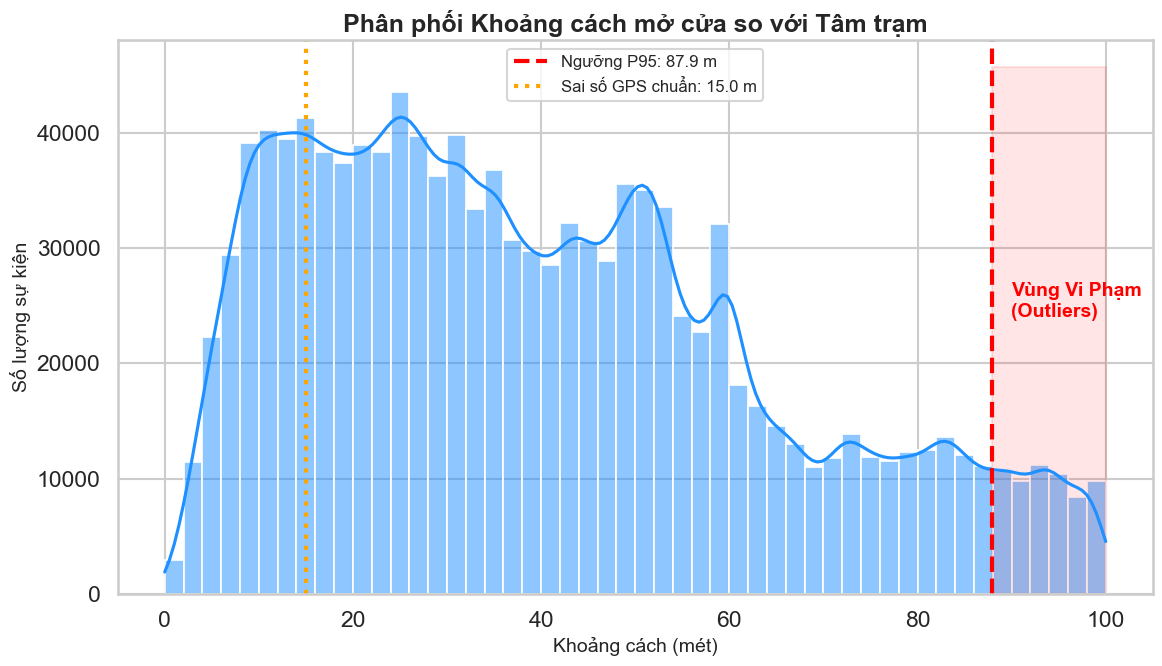

In [23]:
fig1, ax1 = plt.subplots(figsize=(12, 7))

sns.histplot(df_eda['station_distance'], bins=50, kde=True, color="dodgerblue", ax=ax1)
ax1.axvline(p95_distance, color='red', linestyle='--', linewidth=3, 
            label=f'Ngưỡng P95: {p95_distance:.1f} m')
ax1.axvline(15, color='orange', linestyle=':', linewidth=3, 
            label='Sai số GPS chuẩn: 15.0 m')

ax1.set_title('Phân phối Khoảng cách mở cửa so với Tâm trạm', fontsize=18, fontweight='bold')
ax1.set_xlabel('Khoảng cách (mét)', fontsize=14)
ax1.set_ylabel('Số lượng sự kiện', fontsize=14)
ax1.legend(fontsize=12)

# Tô màu vùng vi phạm
ax1.fill_betweenx([0, ax1.get_ylim()[1]], p95_distance, df_eda['station_distance'].max(), color='red', alpha=0.1)
ax1.text(p95_distance + 2, ax1.get_ylim()[1]*0.5, 'Vùng Vi Phạm\n(Outliers)', 
         color='red', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# EDA for gold layer

In [ ]:
df_eda = pd.read_parquet(gold_data_path, engine='pyarrow')
dfi.export(df_eda.describe(include='all'), image_dir + 'eda_silver.png', table_conversion='matplotlib')
df_eda = df_eda[((df_eda['door_up'] == True) | (df_eda['door_down'] == True))].copy()
df_eda = df_eda[(df_eda['avg_speed'] < 100)]
p95_distance = df_eda['avg_speed'].quantile(0.95)

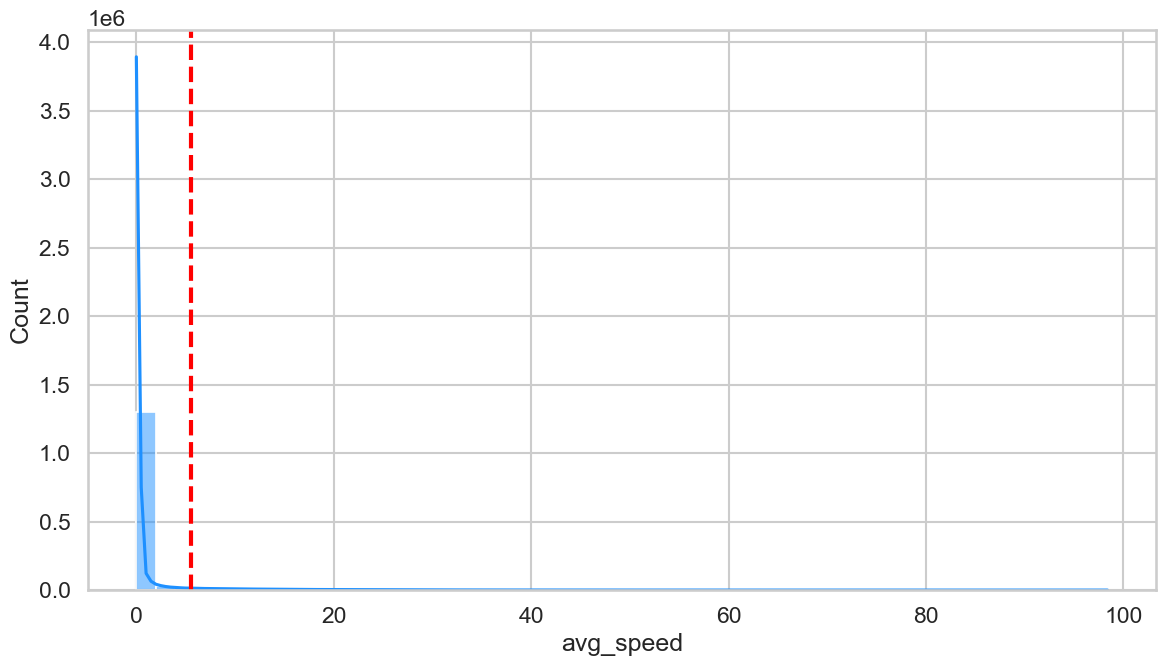

In [27]:
fig1, ax1 = plt.subplots(figsize=(12, 7))
sns.histplot(df_eda['avg_speed'], bins=50, kde=True, color="dodgerblue", ax=ax1)
ax1.axvline(p95_distance, color='red', linestyle='--', linewidth=3, 
            label=f'Ngưỡng P95: {p95_distance:.1f} m')
plt.tight_layout()
plt.show()

In [28]:
df_eda = pd.read_parquet(gold_data_path, engine='pyarrow')
dfi.export(df_eda.describe(include='all'), image_dir + 'eda_silver.png', table_conversion='matplotlib')
df_eda = df_eda[((df_eda['door_up'] == True) | (df_eda['door_down'] == True))].copy()
df_eda = df_eda[(df_eda['speed'] < 100)]
p95_distance = df_eda['speed'].quantile(0.95)

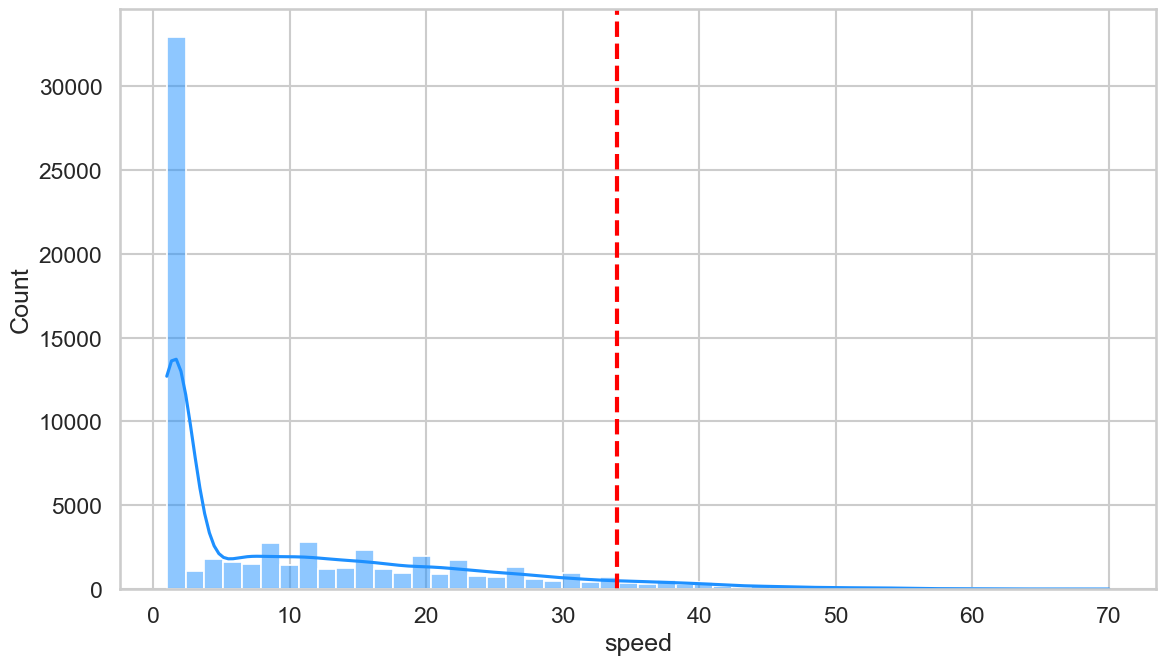

In [30]:
fig1, ax1 = plt.subplots(figsize=(12, 7))
sns.histplot(df_eda['speed'], bins=50, kde=True, color="dodgerblue", ax=ax1)
ax1.axvline(p95_distance, color='red', linestyle='--', linewidth=3, 
            label=f'Ngưỡng P95: {p95_distance:.1f} m')
plt.tight_layout()
plt.show()

In [4]:
def method_3_visual_heatmap(jam_df, output_html= image_dir + "/blackspots_heatmap.html"):
    print("Cách 3: Phân tích Điểm đen bằng Thị giác (Heatmap)...")
    
    # Lấy tọa độ trung tâm TP.HCM
    m = folium.Map(location=[10.7769, 106.7009], zoom_start=12, tiles='CartoDB dark_matter')
    heat_data = jam_df[['y', 'x']].values.tolist()
    
    # Thêm Heatmap
    HeatMap(
        heat_data,
        radius=15, # Độ to của Điểm đen
        blur=10,   # Độ hòa trộn
        max_zoom=1,
        gradient={0.4: 'blue', 0.65: 'yellow', 1.0: 'red'} # Điểm đen nhất sẽ có màu đỏ
    ).add_to(m)
    
    m.save(output_html)
    print(f"Đã xuất bản đồ. Vui lòng mở file {output_html} để xác định Điểm đen bằng mắt thường.")
df_eda = pd.read_parquet(silver_data_path, engine='pyarrow')
method_3_visual_heatmap(df_eda)

Cách 3: Phân tích Điểm đen bằng Thị giác (Heatmap)...
Đã xuất bản đồ. Vui lòng mở file d:\Bus-Status-Analysis-Prediction/images//blackspots_heatmap.html để xác định Điểm đen bằng mắt thường.
